In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Exploratory Data Analysis (EDA)

C:\Users\guscr\AppData\Local\Temp\ipykernel_27584\924616913.py:2: DtypeWarning: Columns (26) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('france_accidents_2023_2024_cleaned.csv')
C:\Users\guscr\AppData\Local\Temp\ipykernel_27584\924616913.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='target_severe', data=df, palette='viridis')


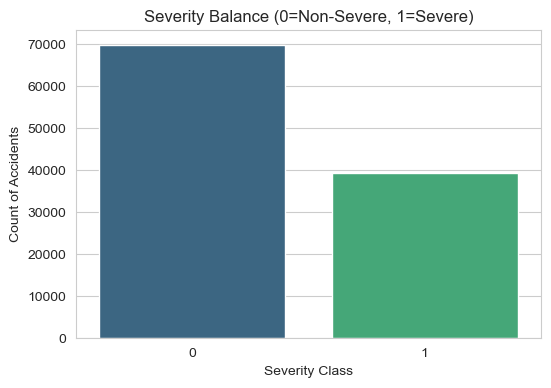

Total Accidents: 109214
Severe Accidents (Rate): 36.11%


In [3]:
# Load the CLEANED dataset
df = pd.read_csv('france_accidents_2023_2024_cleaned.csv')

# Set style
sns.set_style("whitegrid")

# 1. Target Distribution
plt.figure(figsize=(6, 4))
sns.countplot(x='target_severe', data=df, palette='viridis')
plt.title('Severity Balance (0=Non-Severe, 1=Severe)')
plt.xlabel('Severity Class')
plt.ylabel('Count of Accidents')
plt.show()

print(f"Total Accidents: {len(df)}")
print(f"Severe Accidents (Rate): {round(df['target_severe'].mean() * 100, 2)}%")

# Temporal Analysis

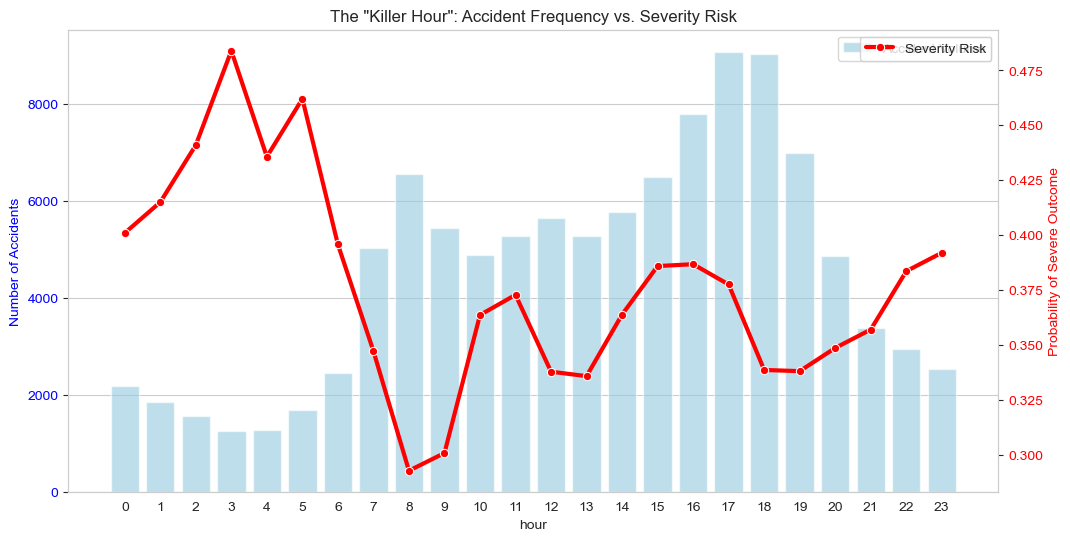

In [4]:
# Group by Hour
hourly_stats = df.groupby('hour').agg(
    count=('target_severe', 'count'),
    risk=('target_severe', 'mean')
).reset_index()

# Create Dual-Axis Plot
fig, ax1 = plt.subplots(figsize=(12, 6))

# Bar Chart: Volume (Blue)
sns.barplot(x='hour', y='count', data=hourly_stats, color='skyblue', alpha=0.6, ax=ax1, label='Accident Volume')
ax1.set_ylabel('Number of Accidents', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

# Line Chart: Risk (Red)
ax2 = ax1.twinx()
sns.lineplot(x='hour', y='risk', data=hourly_stats, color='red', marker='o', linewidth=3, ax=ax2, label='Severity Risk')
ax2.set_ylabel('Probability of Severe Outcome', color='red')
ax2.tick_params(axis='y', labelcolor='red')

plt.title('The "Killer Hour": Accident Frequency vs. Severity Risk')
plt.grid(visible=False)
plt.show()

Most accidents happen during rush hour, the deadliest accidents happen at night (likely due to speed, alcohol, or visibility)

# Weather and Light Conditions

C:\Users\guscr\AppData\Local\Temp\ipykernel_27584\877946141.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Lighting', y='target_severe', data=df_viz, order=['Daylight', 'Twilight', 'Night (Light On)', 'Night (No Light)'], palette='magma', ax=ax[0])
C:\Users\guscr\AppData\Local\Temp\ipykernel_27584\877946141.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Weather', y='target_severe', data=df_viz, order=['Normal', 'Light Rain', 'Heavy Rain', 'Snow', 'Fog'], palette='Blues', ax=ax[1])


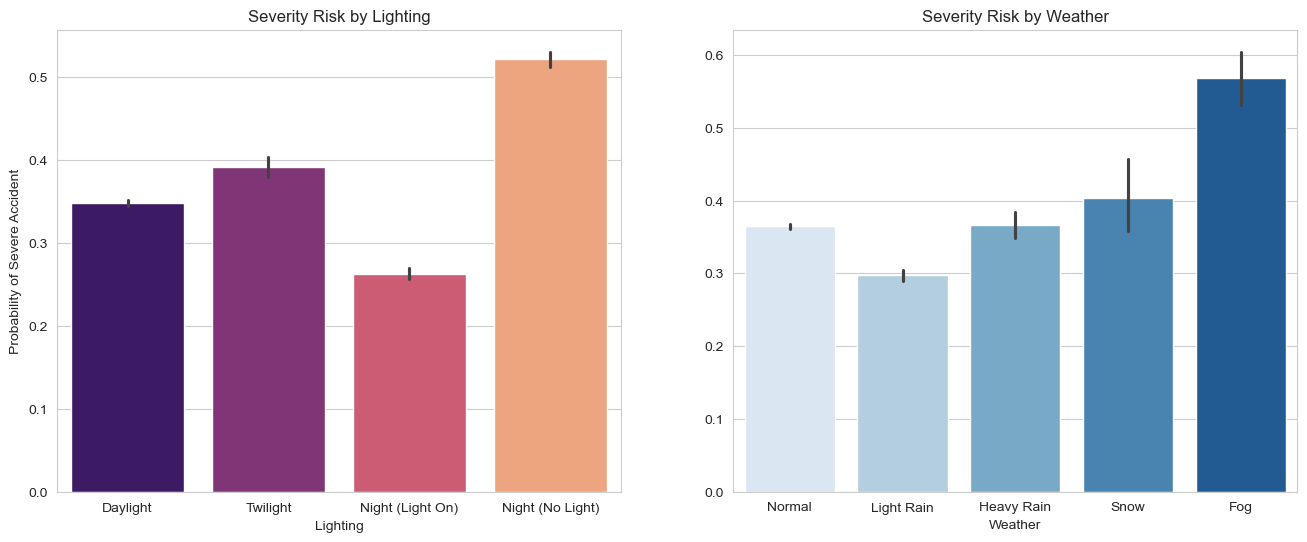

In [5]:
# Mapping codes to text for better graphs
lum_labels = {1: 'Daylight', 2: 'Twilight', 3: 'Night (No Light)', 5: 'Night (Light On)'}
weather_labels = {1: 'Normal', 2: 'Light Rain', 3: 'Heavy Rain', 4: 'Snow', 5: 'Fog'}

# Create a copy for visualization
df_viz = df.copy()
df_viz['Lighting'] = df_viz['lum'].map(lum_labels)
df_viz['Weather'] = df_viz['atm'].map(weather_labels)

# Filter out unmapped codes
df_viz = df_viz.dropna(subset=['Lighting', 'Weather'])

fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Lighting Risk
sns.barplot(x='Lighting', y='target_severe', data=df_viz, order=['Daylight', 'Twilight', 'Night (Light On)', 'Night (No Light)'], palette='magma', ax=ax[0])
ax[0].set_title('Severity Risk by Lighting')
ax[0].set_ylabel('Probability of Severe Accident')

# Plot 2: Weather Risk
sns.barplot(x='Weather', y='target_severe', data=df_viz, order=['Normal', 'Light Rain', 'Heavy Rain', 'Snow', 'Fog'], palette='Blues', ax=ax[1])
ax[1].set_title('Severity Risk by Weather')
ax[1].set_ylabel('')

plt.show()

# Risk Zones

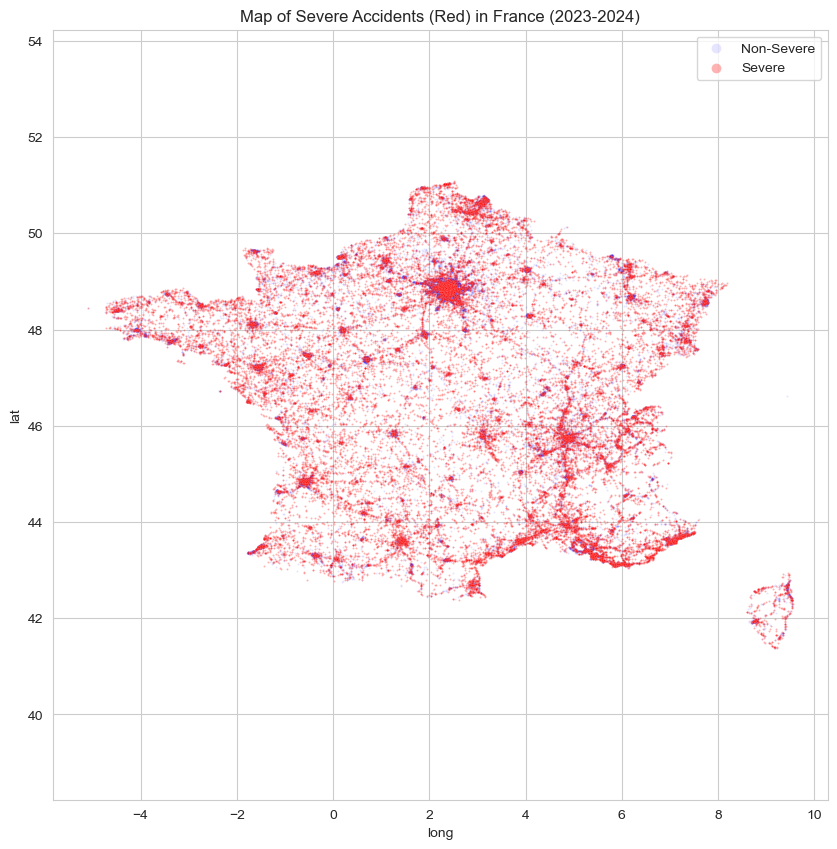

In [6]:
plt.figure(figsize=(10, 10))

# Filter for mainland France coordinates to avoid outliers (colonies, bad data)
# Approx bounding box: Lat 41-52, Long -5 to 10
mask_geo = (df['lat'] > 41) & (df['lat'] < 52) & (df['long'] > -6) & (df['long'] < 10)
geo_data = df[mask_geo]

# Plot: Non-Severe in Blue, Severe in Red
# We plot Severe ON TOP of Non-Severe to make them visible
sns.scatterplot(x='long', y='lat', data=geo_data[geo_data['target_severe']==0], 
                color='blue', s=2, alpha=0.1, label='Non-Severe')

sns.scatterplot(x='long', y='lat', data=geo_data[geo_data['target_severe']==1], 
                color='red', s=2, alpha=0.3, label='Severe')

plt.title('Map of Severe Accidents (Red) in France (2023-2024)')
plt.legend(markerscale=5)
plt.axis('equal')
plt.show()

## Paris

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the data if not already loaded
# df = pd.read_csv('france_accidents_2023_2024_cleaned.csv')

# Define Paris Bounding Box (City Center + immediate surroundings)
paris_mask = (df['lat'] > 48.81) & (df['lat'] < 48.91) & \
             (df['long'] > 2.22) & (df['long'] < 2.47)

df_paris = df[paris_mask].copy()

print(f"Accidents in Paris (2023-2024): {len(df_paris)}")
print(f"Paris Severity Rate: {round(df_paris['target_severe'].mean() * 100, 2)}%")
print(f"National Severity Rate: {round(df['target_severe'].mean() * 100, 2)}%")

Accidents in Paris (2023-2024): 12797
Paris Severity Rate: 9.32%
National Severity Rate: 36.11%


## PAris Map

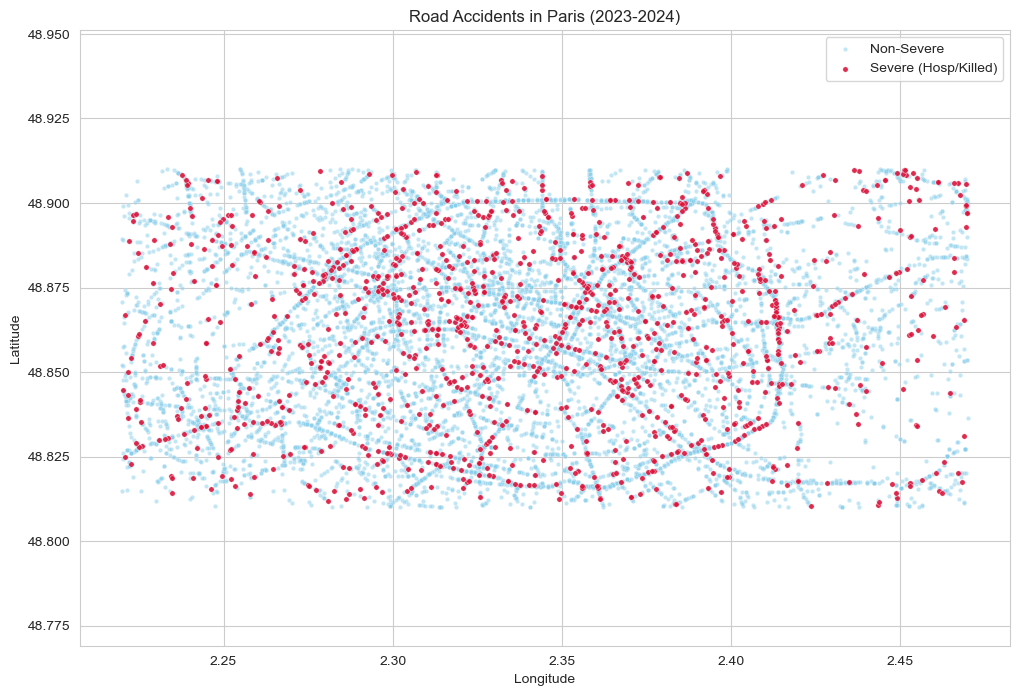

In [17]:
plt.figure(figsize=(12, 8))

# Plot Non-Severe (Blue) first
sns.scatterplot(x='long', y='lat', data=df_paris[df_paris['target_severe']==0], 
                color='skyblue', s=10, alpha=0.5, label='Non-Severe')

# Plot Severe (Red) on top
sns.scatterplot(x='long', y='lat', data=df_paris[df_paris['target_severe']==1], 
                color='crimson', s=15, alpha=0.9, label='Severe (Hosp/Killed)')

plt.title('Road Accidents in Paris (2023-2024)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend()
plt.axis('equal') # Keeps the map not stretched
plt.show()

## Collision type

C:\Users\guscr\AppData\Local\Temp\ipykernel_44828\81279361.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Percentage', y='Collision Type', data=col_counts, palette='magma')


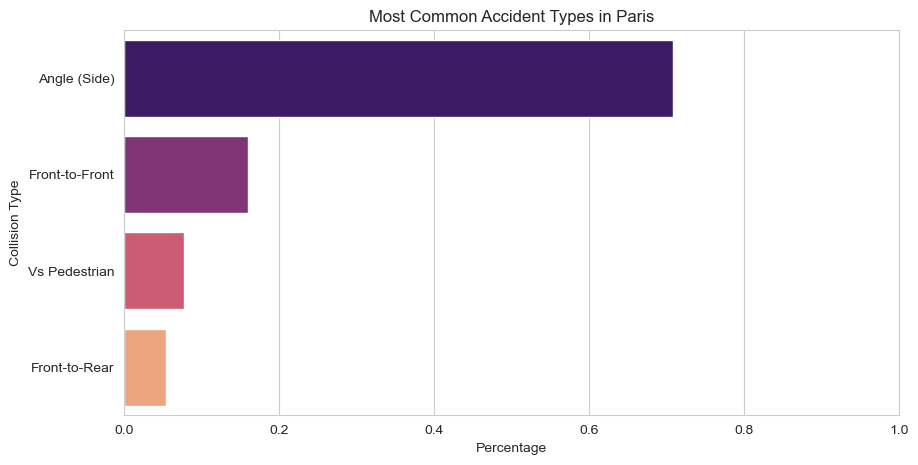

In [18]:
# Collision Dictionary
col_labels = {
    1: 'Front-to-Rear',
    2: 'Front-to-Front',
    3: 'Angle (Side)',
    6: 'Angle (Side)',
    7: 'Vs Pedestrian',
    8: 'Vs Obstacle'
}

# Map labels
df_paris['Collision Type'] = df_paris['col'].map(col_labels)

# Count and Sort
col_counts = df_paris['Collision Type'].value_counts(normalize=True).reset_index()
col_counts.columns = ['Collision Type', 'Percentage']

plt.figure(figsize=(10, 5))
sns.barplot(x='Percentage', y='Collision Type', data=col_counts, palette='magma')
plt.title('Most Common Accident Types in Paris')
plt.xlim(0, 1) # 0 to 100%
plt.show()

# France Risk zones

In [19]:
# 1. Filter for Metropolitan France (Exclude overseas DOM-TOM for the map)
# Approx bounding box: Lat 41-52, Long -6 to 10
mask_france = (df['lat'] > 41) & (df['lat'] < 52) & (df['long'] > -6) & (df['long'] < 10)
df_france = df[mask_france].copy()

# 2. Create Clusters by Rounding Coordinates
# 3 decimal places = approx 100m precision (perfect for intersections)
df_france['lat_cluster'] = df_france['lat'].round(3)
df_france['long_cluster'] = df_france['long'].round(3)

# 3. Aggregation: Count accidents per cluster
risk_zones = df_france.groupby(['lat_cluster', 'long_cluster']).agg(
    total_accidents=('target_severe', 'count'),
    severe_accidents=('target_severe', 'sum'),
    mean_severity=('target_severe', 'mean')
).reset_index()

# 4. Filter & Sort
# We focus on "Black Spots": Locations with HIGH counts of SEVERE accidents
# Filter: At least 3 severe accidents to be considered a "Risk Zone"
black_spots = risk_zones[risk_zones['severe_accidents'] >= 3].copy()

# Sort by the count of severe accidents
top_10_danger = black_spots.sort_values(by='severe_accidents', ascending=False).head(10)

print("Top 10 Most Dangerous Intersections/Zones in France (2023-2024):")
display(top_10_danger)

Top 10 Most Dangerous Intersections/Zones in France (2023-2024):


,lat_cluster,long_cluster,total_accidents,severe_accidents,mean_severity
43952,47.906,1.869,6,4,0.666667
52968,48.652,2.273,4,4,1.000000
65052,48.880,2.313,6,4,0.666667
4912,43.291,5.381,9,4,0.444444
33282,46.464,-0.801,4,4,1.000000
59800,48.826,2.357,9,3,0.333333
63350,48.863,2.313,16,3,0.187500
62425,48.853,2.377,5,3,0.600000
61191,48.840,2.382,5,3,0.600000
60612,48.835,2.267,9,3,0.333333


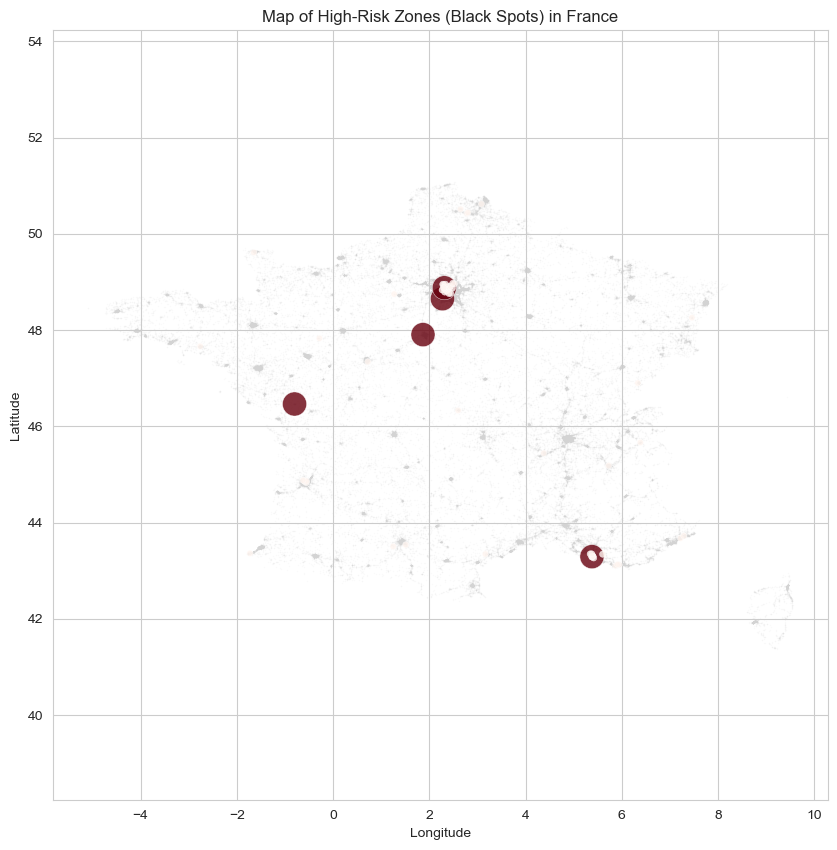

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))

# Layer 1: Background - All accidents (Light Grey dots to show the road network)
sns.scatterplot(x='long', y='lat', data=df_france, 
                color='lightgrey', s=1, alpha=0.1)

# Layer 2: The Risk Zones (Red Bubbles)
# We plot the top 200 zones so the map isn't too cluttered
top_200_zones = black_spots.sort_values(by='severe_accidents', ascending=False).head(200)

sns.scatterplot(x='long_cluster', y='lat_cluster', data=top_200_zones,
                size='severe_accidents', sizes=(20, 300), 
                hue='severe_accidents', palette='Reds',
                alpha=0.8, legend=False)

plt.title('Map of High-Risk Zones (Black Spots) in France')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.axis('equal')
plt.show()